# Question 2

In [1]:
!pip install numpy
!pip install pandas
!pip install "networkx >= 2.6"
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
  Using cached matplotlib-3.10.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)


In [2]:
import networkx as nx
from packaging import version
import sys 

print("Python version:", sys.version)
print("networkx version:", nx.__version__)

# assert networkx version is greater or equal to 2.6
assert version.parse(nx.__version__) >= version.parse("3.0")

# assert python version is greater that 3.7
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 7 

# If working in colab mount the drive filesystem 
if 'google.colab' in str(get_ipython()):
    print('Working in colab')
    
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("working locally")

Python version: 3.11.11 (main, Mar 14 2026, 01:14:19) [GCC 12.2.0]
networkx version: 3.6.1
working locally


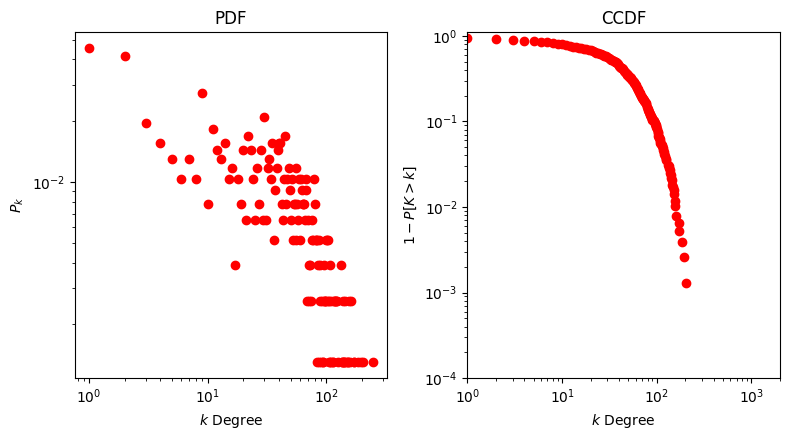

In [3]:
import csv 
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

GCaltech = nx.read_gml("data/Caltech36.gml")
        
e = GCaltech.number_of_edges()
N = GCaltech.number_of_nodes()
D = e / (N*(N-1))

degree = [v for k,v in dict(GCaltech.degree()).items()]
distribution = [(elem, degree.count(elem)) for elem in sorted(set(degree))]
k,pk = zip(*distribution)
PDF = np.array(pk)/sum(pk)
CCDF = 1-np.cumsum(PDF)


#
# Plots 
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16/2,9/2))
ax1.loglog(k, PDF, 'ro')
ax1.set_xlabel("$k$ Degree")
ax1.set_ylabel("$P_k$")
ax1.set_title("PDF")

ax2.loglog(k, CCDF, 'ro')
ax2.set_ylim(1e-4,1.1)
ax2.set_xlim(1,2e3)
ax2.set_xlabel("$k$ Degree")
ax2.set_ylabel("$1-P[K > k]$")
ax2.set_title("CCDF")
fig.tight_layout()